<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Erb%2C%20C.%20B.%2C%20%26%20Harvey%2C%20C.%20R.%20(2013).%20The%20golden%20dilemma/Gold_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd

There are many different sources to get the gold price. The dataset expresses medieval gold values in modern USD per troy ounce, meaning the prices are reconstructed using historical currency and metal‑value conversions, not actual U.S. dollars that existed at the time.

In [18]:
import pandas as pd

#Denominated in US dollars per troy ounce.
github_url = "https://raw.githubusercontent.com/datasets/gold-prices/main/data/monthly.csv"
gold_1833_df = pd.read_csv(github_url)

#Adds the 01 to each of these
gold_1833_df['Date'] = pd.to_datetime(gold_1833_df['Date'], format='%Y-%m')
gold_1833_df.set_index('Date', inplace=True)
print(gold_1833_df)


free_gold_url = "https://freegoldapi.com/data/latest.csv"
gold_1258_df = pd.read_csv(free_gold_url, dtype={'date': str})
print(gold_1258_df)

              Price
Date               
1833-01-01    18.93
1833-02-01    18.93
1833-03-01    18.93
1833-04-01    18.93
1833-05-01    18.93
...             ...
2025-10-01  4058.33
2025-11-01  4087.19
2025-12-01  4309.23
2026-01-01  4752.75
2026-02-01  5019.97

[2318 rows x 1 columns]
            date        price                        source
0     1258-01-01     0.890000  measuringworth_british (GBP)
1     1259-01-01     0.890000  measuringworth_british (GBP)
2     1260-01-01     0.890000  measuringworth_british (GBP)
3     1261-01-01     0.890000  measuringworth_british (GBP)
4     1262-01-01     0.890000  measuringworth_british (GBP)
...          ...          ...                           ...
1764  2026-02-13  5022.000000                 yahoo_finance
1765  2026-02-17  4882.899902                 yahoo_finance
1766  2026-02-18  4986.500000                 yahoo_finance
1767  2026-02-19  4975.899902                 yahoo_finance
1768  2026-02-20  5059.299805                 yahoo_fin

In [31]:
import pandas_datareader.data as web
import datetime

start = datetime.datetime(1947, 1, 1)
end = datetime.datetime(2026, 3, 5)
# Download CPI data (Consumer Price Index for All Urban Consumers, seasonally adjusted) from FRED
cpi = web.DataReader("CPIAUCSL", "fred", start, end)

The interpolate(method='time') function in pandas fills missing values by estimating them based on the surrounding data points using the time index, assuming that the values change linearly over time between known points.

In [26]:
cpi.index = pd.to_datetime(cpi.index)

# Interpolate missing values linearly based on time
cpi['CPIAUCSL'] = cpi['CPIAUCSL'].interpolate(method='time')


We use Pearson correlation because it **measures how strongly and linearly two variables, like Price and CPI, move together**, making it ideal for detecting proportional relationships over time.


In [29]:
cpi_aligned = cpi.reindex(gold_1833_df.index)

cpi_aligned["Price"] = gold_1833_df["Price"]

cpi_aligned = cpi_aligned.dropna()

print(cpi_aligned)
# Calculate Pearson correlation
correlation = cpi_aligned['CPIAUCSL'].corr(cpi_aligned['Price'])
print(f"Correlation between CPI and Price: {correlation:.4f}")

              CPIAUCSL    Price
Date                           
1947-01-01   21.480000    34.71
1947-02-01   21.620000    34.71
1947-03-01   22.000000    34.71
1947-04-01   22.000000    34.71
1947-05-01   21.950000    34.71
...                ...      ...
2025-09-01  324.245000  3667.68
2025-10-01  324.647295  4058.33
2025-11-01  325.063000  4087.19
2025-12-01  326.031000  4309.23
2026-01-01  326.588000  4752.75

[949 rows x 2 columns]
Correlation between CPI and Price: 0.8636


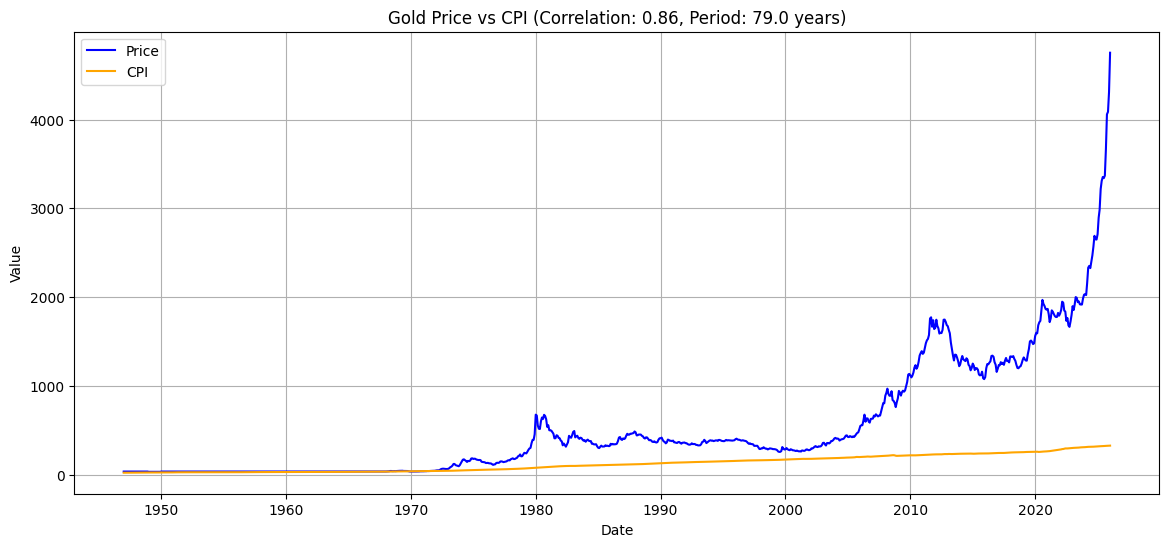

In [32]:
import matplotlib.pyplot as plt

years = (cpi_aligned.index[-1] - cpi_aligned.index[0]).days / 365.25

plt.figure(figsize=(14,6))

# Plot Price
plt.plot(cpi_aligned.index, cpi_aligned['Price'], label='Price', color='blue')

# Plot CPI on the same graph (scaled for visualization)
plt.plot(cpi_aligned.index, cpi_aligned['CPIAUCSL'], label='CPI', color='orange')

plt.title(f"Gold Price vs CPI (Correlation: {correlation:.2f}, Period: {years:.1f} years)")
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The above result is misleading because both the CPI and the gold price have postive trend or increase over time. So it makes them look more correlated then they actually are.We take differences (monthly or yearly) to remove the long-term upward trend in gold prices and CPI, so the correlation measures actual co-movement rather than being inflated simply because both series naturally increase over time.

In [47]:
# Month-to-month changes
cpi_aligned['Price_diff_1m'] = cpi_aligned['Price'].diff(1)
cpi_aligned['CPI_diff_1m'] = cpi_aligned['CPIAUCSL'].diff(1)
diff_1m = cpi_aligned.dropna(subset=['Price_diff_1m','CPI_diff_1m'])
corr_1m = diff_1m['Price_diff_1m'].corr(diff_1m['CPI_diff_1m'])
print(f"Correlation of monthly changes: {corr_1m:.4f}")

# Year-to-year changes (12 months)
cpi_aligned['Price_diff_1y'] = cpi_aligned['Price'].diff(12)
cpi_aligned['CPI_diff_1y'] = cpi_aligned['CPIAUCSL'].diff(12)
diff_1y = cpi_aligned.dropna(subset=['Price_diff_1y','CPI_diff_1y'])
corr_1y = diff_1y['Price_diff_1y'].corr(diff_1y['CPI_diff_1y'])
print(f"Correlation of yearly changes: {corr_1y:.4f}")

# 5-year changes (60 months)
cpi_aligned['Price_diff_5y'] = cpi_aligned['Price'].diff(60)
cpi_aligned['CPI_diff_5y'] = cpi_aligned['CPIAUCSL'].diff(60)
diff_5y = cpi_aligned.dropna(subset=['Price_diff_5y','CPI_diff_5y'])
corr_5y = diff_5y['Price_diff_5y'].corr(diff_5y['CPI_diff_5y'])
print(f"Correlation of 5-year changes: {corr_5y:.4f}")

# 10-year changes (120 months)
cpi_aligned['Price_diff_10y'] = cpi_aligned['Price'].diff(120)
cpi_aligned['CPI_diff_10y'] = cpi_aligned['CPIAUCSL'].diff(120)
diff_10y = cpi_aligned.dropna(subset=['Price_diff_10y','CPI_diff_10y'])
corr_10y = diff_10y['Price_diff_10y'].corr(diff_10y['CPI_diff_10y'])
print(f"Correlation of 10-year changes: {corr_10y:.4f}")

# 20-year changes (240 months)
cpi_aligned['Price_diff_20y'] = cpi_aligned['Price'].diff(240)
cpi_aligned['CPI_diff_20y'] = cpi_aligned['CPIAUCSL'].diff(240)
diff_20y = cpi_aligned.dropna(subset=['Price_diff_20y','CPI_diff_20y'])
corr_20y = diff_10y['Price_diff_20y'].corr(diff_20y['CPI_diff_20y'])
print(f"Correlation of 20-year changes: {corr_20y:.4f}")

Correlation of monthly changes: 0.1452
Correlation of yearly changes: 0.2464
Correlation of 5-year changes: 0.6260
Correlation of 10-year changes: 0.5221
Correlation of 20-year changes: 0.5162


Gold’s alignment with inflation strengthens over multi-year horizons, but it remains a moderate, inconsistent hedge, particularly in the short term.
Something like a TIPS (Treasury Inflation-Protected Securities) that are explicity pegged to the CPI usually have at minimum 0.9 correlation with CPI.

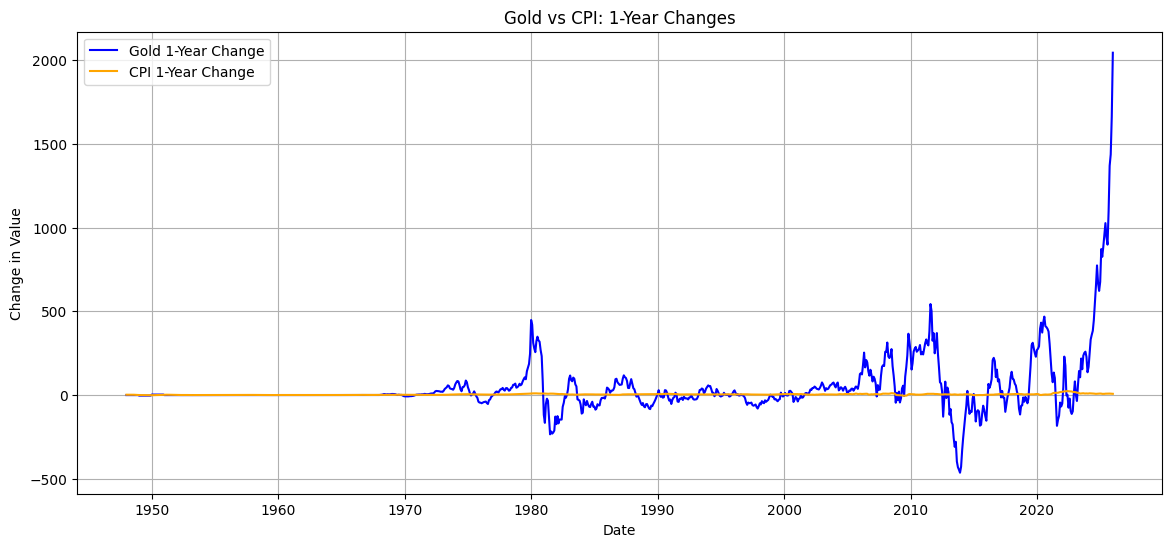

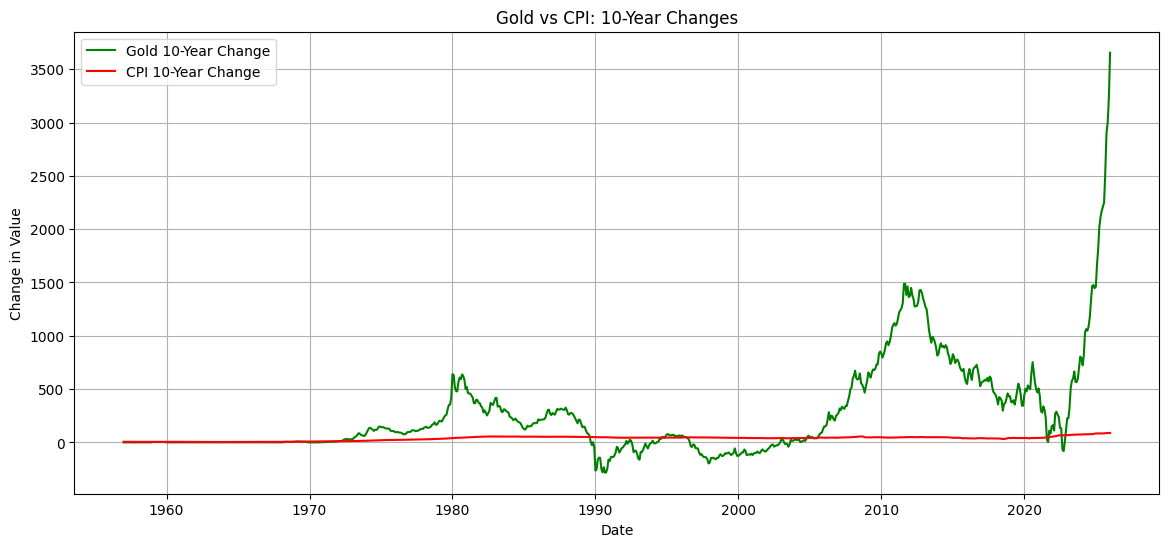

In [53]:
# -----------------------------
# Plot 1-Year Changes
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(diff_1y.index, diff_1y['Price_diff_1y'], label='Gold 1-Year Change', color='blue')
plt.plot(diff_1y.index, diff_1y['CPI_diff_1y'], label='CPI 1-Year Change', color='orange')
plt.title('Gold vs CPI: 1-Year Changes')
plt.xlabel('Date')
plt.ylabel('Change in Value')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Plot 10-Year Changes
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(diff_10y.index, diff_10y['Price_diff_10y'], label='Gold 10-Year Change', color='green')
plt.plot(diff_10y.index, diff_10y['CPI_diff_10y'], label='CPI 10-Year Change', color='red')
plt.title('Gold vs CPI: 10-Year Changes')
plt.xlabel('Date')
plt.ylabel('Change in Value')
plt.legend()
plt.grid(True)
plt.show()

**Inflation Explanatory Power on Gold Returns**

This code runs regressions of gold price changes on CPI changes across multiple time horizons, from monthly to twenty years. For each period, it computes differences, fits a linear model, and outputs the CPI coefficient, R-squared, and p-value. This allows us to assess how strongly inflation explains gold price movements over short, medium, and long-term horizons.

In [52]:
import statsmodels.api as sm

# Dictionary to store results
regression_results = {}

# Define the time periods and corresponding columns
time_periods = {
    '1m': ('Price_diff_1m','CPI_diff_1m'),
    '1y': ('Price_diff_1y','CPI_diff_1y'),
    '5y': ('Price_diff_5y','CPI_diff_5y'),
    '10y': ('Price_diff_10y','CPI_diff_10y'),
    '20y': ('Price_diff_20y','CPI_diff_20y')
}

# Loop through each time period
for period, (price_col, cpi_col) in time_periods.items():
    # Drop NaNs
    df = cpi_aligned.dropna(subset=[price_col, cpi_col])

    # Dependent and independent variables
    Y = df[price_col]
    X = sm.add_constant(df[cpi_col])  # add intercept

    # Fit regression
    model = sm.OLS(Y, X).fit()

    # Store results
    regression_results[period] = model

    # Print summary info
    print(f"--- Regression for {period} changes ---")
    print(f"CPI coefficient: {model.params[cpi_col]:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"P-value: {model.pvalues[cpi_col]:.4f}")
    print("\n")

--- Regression for 1m changes ---
CPI coefficient: 11.4357
R-squared: 0.0211
P-value: 0.0000


--- Regression for 1y changes ---
CPI coefficient: 12.3336
R-squared: 0.0607
P-value: 0.0000


--- Regression for 5y changes ---
CPI coefficient: 16.7514
R-squared: 0.3919
P-value: 0.0000


--- Regression for 10y changes ---
CPI coefficient: 11.8263
R-squared: 0.2726
P-value: 0.0000


--- Regression for 20y changes ---
CPI coefficient: 10.3029
R-squared: 0.2665
P-value: 0.0000




The regression analysis of gold price changes on CPI changes across different time horizons reveals a clear pattern. In the short term, monthly and yearly changes show very low explanatory power, with R-squared values of 0.021 and 0.061 respectively, indicating that gold prices respond only weakly to inflation over these periods. However, as the horizon lengthens, the relationship strengthens: over 5-year periods, the R-squared rises to 0.392, suggesting that inflation explains a meaningful portion of medium-term gold price movements. For 10- and 20-year horizons, R-squared values remain moderate (~0.27), showing that gold partially tracks inflation in the long term, but other factors also influence its price. All CPI coefficients are positive and statistically significant, confirming that higher inflation tends to coincide with higher gold prices, though the effect is strongest over longer periods.

**Long Term Real Returns**

In [48]:
# Real gold price = nominal gold price divided by CPI, scaled
cpi_aligned['Gold_real'] = cpi_aligned['Price'] / cpi_aligned['CPIAUCSL'] * 100  # scale to 100 at base CPI


In [49]:
gold_start = cpi_aligned['Gold_real'].iloc[0]
gold_end = cpi_aligned['Gold_real'].iloc[-1]

total_real_return = (gold_end / gold_start - 1) * 100
print(f"Total real return from {cpi_aligned.index[0].date()} to {cpi_aligned.index[-1].date()}: {total_real_return:.2f}%")

Total real return from 1947-01-01 to 2026-01-01: 800.58%


In [50]:
years = (cpi_aligned.index[-1] - cpi_aligned.index[0]).days / 365.25
cagr_real = (gold_end / gold_start) ** (1/years) - 1
print(f"Annualized real return (CAGR): {cagr_real*100:.2f}% per year")

Annualized real return (CAGR): 2.82% per year
